<a href="https://colab.research.google.com/github/gauravpatra03-sketch/Deep-Learning/blob/main/GenAI_Week1_Ex2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Import libraries

In [4]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

Load dataset

In [5]:
(x_train, y_train), (x_test, y_test) =datasets.cifar10.load_data()

#Normalize pixel values to [0,1]
x_train=x_train/255.0
x_test=x_test/255.0

class_names=[
    'airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck'
]

print("Training data shape: ",x_train.shape)
print("Testing data shape: ",x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2115s 12us/step
Training data shape:  (50000, 32, 32, 3)
Testing data shape:  (10000, 32, 32, 3)


Define model 1

In [6]:
def create_cnn1():

  model=tf.keras.Sequential([
      layers.Conv2D(32,(3,3), activation='relu', input_shape=(32,32,3)), layers.MaxPooling2D((2,2)),

      layers.Conv2D(64,(3,3), activation='relu'), layers.MaxPooling2D((2,2)),

      layers.Flatten(),
      layers.Dense(128, activation='relu'),
      layers.Dense(10,activation='softmax')
  ])

  return model

Define model 2

In [7]:
def create_cnn2():

  model=tf.keras.Sequential([
      layers.Conv2D(32,(3,3), input_shape=(32,32,3)),
      layers.BatchNormalization(),
      layers.Activation('relu'),
      layers.MaxPooling2D((2,2)),

      layers.Conv2D(64,(3,3)),
      layers.BatchNormalization(),
      layers.Activation('relu'),
      layers.MaxPooling2D((2,2)),

      layers.Flatten(),
      layers.Dense(128, activation='relu'),
      layers.Dense(10,activation='softmax')
  ])

  return model

Define model 3

In [8]:
def create_cnn3():

  model=tf.keras.Sequential([
      layers.Conv2D(32,(3,3), activation='relu', input_shape=(32,32,3)),
      layers.MaxPooling2D((2,2)),

      layers.Conv2D(64,(3,3), activation='relu'),
      layers.MaxPooling2D((2,2)),

      layers.Flatten(),

      layers.Dense(128, activation='relu'),

      layers.Dropout(0.5),

      layers.Dense(10, activation='softmax')
  ])

  return model

Build ensemble model

In [9]:
model1=create_cnn1()
model2=create_cnn2()
model3=create_cnn3()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [11]:
for model in [model1,model2,model3]:
  model.compile(
      optimizer='adam',
      loss='sparse_categorical_crossentropy',
      metrics=['accuracy']
  )

In [12]:
history1=model1.fit(
    x_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

history2=model2.fit(
    x_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

history3=model3.fit(
    x_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 55s 85ms/step - accuracy: 0.4473 - loss: 1.5412 - val_accuracy: 0.5306 - val_loss: 1.3264
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 83s 87ms/step - accuracy: 0.5813 - loss: 1.1824 - val_accuracy: 0.6041 - val_loss: 1.1226
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 78s 81ms/step - accuracy: 0.6421 - loss: 1.0217 - val_accuracy: 0.6471 - val_loss: 1.0155
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 51s 82ms/step - accuracy: 0.6787 - loss: 0.9197 - val_accuracy: 0.6523 - val_loss: 1.0008
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 82s 83ms/step - accuracy: 0.7022 - loss: 0.8510 - val_accuracy: 0.6826 - val_loss: 0.9269
Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 80s 125ms/step - accuracy: 0.5101 - loss: 1.3771 - val_accuracy: 0.4543 - val_loss: 1.5277
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 75s 119ms/step - accuracy: 0.6355 - loss: 1.0329 - val_accuracy: 0.5162 - val_loss: 1.4721
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 82s 119ms/step - accuracy: 0.6814 - loss: 0.9101 - val_a

Predictions

Average Predictions

In [13]:
pred1=model1.predict(x_test)
pred2=model2.predict(x_test)
pred3=model3.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step


In [14]:
ensemble_pred=(
    pred1+pred2+pred3
)/3

In [15]:
y_pred=np.argmax(
    ensemble_pred,
    axis=1
)

Ensemble accuracy

In [16]:
from sklearn.metrics import accuracy_score

acc=accuracy_score(
    y_test,
    y_pred
)

print("Ensemble Accuracy: ",acc)

Ensemble Accuracy:  0.6935


Confusion matrix

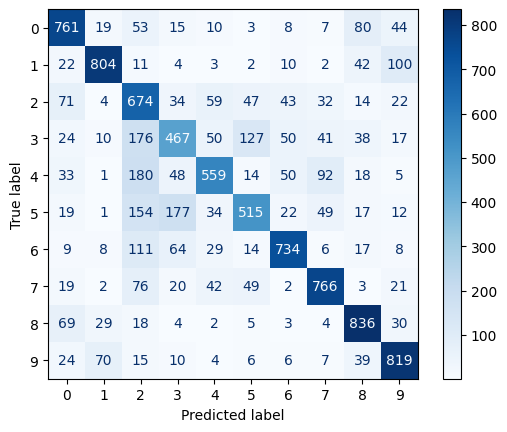

In [18]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

cm=confusion_matrix(
    y_test,
    y_pred
)

disp=ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot(cmap='Blues')

plt.show()